In [50]:
import os
import numpy as np
import globals as gl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pcm_models import find_model
import PcmPy as pcm
from matplotlib.cm import ScalarMappable
import pickle
from matplotlib.colors import LinearSegmentedColormap, Normalize

plt.style.use('default')

In [51]:
rois = ['M2', 'M3', 'D3']
H = 'R'
experiment = 'smp2'
glm = 12

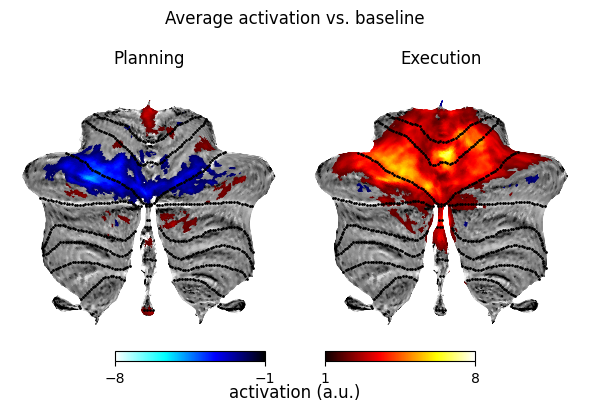

In [52]:
from vis import plot_flatmap_cerebellar_activation

cold_colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (1, 1, 1)]  # RGB tuples
cold = LinearSegmentedColormap.from_list('cold_custom', cold_colors, N=128)
hot = plt.cm.hot(np.linspace(0, 1, 128))
cold_vals = cold(np.linspace(1, 0, 128))  # reversed
combined = np.vstack((cold_vals, hot))
cmap = LinearSegmentedColormap.from_list('coldhot', combined)

dtype = 'con'

vmin, vmax = -8, 8
thresh = 1

img = os.path.join(gl.baseDir, experiment, 'SUIT', f'glm{glm}.{dtype}.flat.surf.gii')
fig, axs = plot_flatmap_cerebellar_activation(img, vmin=vmin, vmax=vmax, thresh=1, figsize=(6, 4), cbar_fraction=.01, cmap=cmap)
fig.suptitle(f'Average activation vs. baseline')
fig.subplots_adjust(top=0.85, bottom=.1, wspace=0, hspace=0.1, right=.9, left=0)

cold_half = LinearSegmentedColormap.from_list("cold_half", combined[:128])
hot_half = LinearSegmentedColormap.from_list("hot_half", combined[128:])

neg_norm = Normalize(vmin=vmin, vmax=-thresh)
sm_neg = ScalarMappable(norm=neg_norm, cmap=cold_half)
cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=axs, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

pos_norm = Normalize(vmin=thresh, vmax=vmax)
sm_pos = ScalarMappable(norm=pos_norm, cmap=hot_half)
cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=axs, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.tight_layout()

plt.show()

M2: tval=1.7954798265673229, pval=0.09778229730955129
M3: tval=0.7087620250888469, pval=0.4920123024927595
D3: tval=2.279000622545713, pval=0.04175361011935496


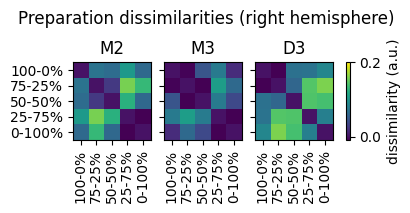

In [53]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .2

fig, axs = plt.subplots(1, len(rois), figsize=(4, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_dissimilarities(fig, axs, r, G, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.015)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Preparation dissimilarities (right hemisphere)')

plt.show()

cue vs. uncertainty, tval=1.6742501155662486, pval=0.11992461869138432
cue vs. uncertainty, tval=0.9222037464544599, pval=0.3745920631295967
cue vs. uncertainty, tval=1.654165967678227, pval=0.12399421424433794


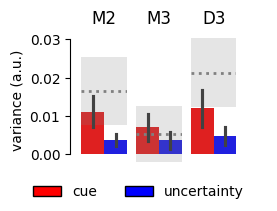

In [54]:
from vis import plot_var_expl, add_sig_var_expl

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.p'), 'component')
n_param_c = Mc.n_param
components = ['cue', 'uncertainty']
palette = ['red', 'blue']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(2, 2), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    G = np.load(os.path.join(gl.baseDir, experiment, 'SUIT',gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_var_expl(fig, axs, r, G, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, 'SUIT',gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[1], axs[0].get_yticks()[-2])
plt.show()

M2: tval=1.385537677632121, pval=0.1911003153416779
M3: tval=2.215727077826328, pval=0.046796481599700485
D3: tval=0.938635924612539, pval=0.36642693795081105


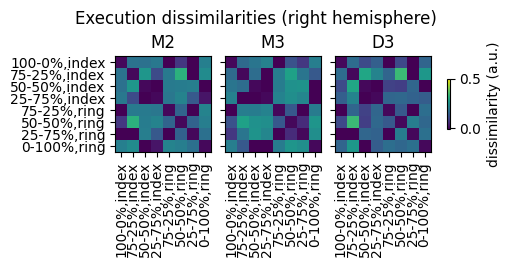

In [55]:
vmin, vmax = -.01, .5

fig, axs = plt.subplots(1, len(rois), figsize=(5, 2.5),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_dissimilarities(fig, axs, r, G, list(gl.regressor_mapping.keys())[5:13], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Execution dissimilarities (right hemisphere)')

plt.show()

finger vs. cue, tval=-0.533435652706077, pval=0.6034722138858521
finger vs. surprise, tval=1.5935538654843757, pval=0.13702040216018624
cue vs. surprise, tval=2.1824938147279376, pval=0.049671477836550765
finger vs. cue, tval=0.5626173617169506, pval=0.584053454250438
finger vs. surprise, tval=1.76571173197555, pval=0.10285054500145312
cue vs. surprise, tval=1.7685895957247846, pval=0.102350466849518
finger vs. cue, tval=-1.3578149377181183, pval=0.19950641631727184
finger vs. surprise, tval=1.0968646739149652, pval=0.29422415131334495
cue vs. surprise, tval=1.976377541315473, pval=0.07155550473955326


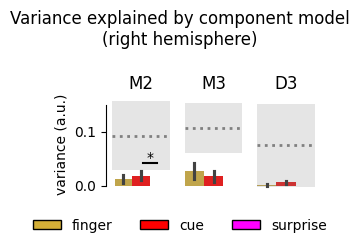

In [56]:
Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.p'), 'component')
n_param_c = Mc.n_param
components = ['finger', 'cue', 'surprise']
palette = ['#D4AF37', 'red', 'magenta']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(3, 2), sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, 'SUIT',gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    G = np.load(os.path.join(gl.baseDir, experiment,'SUIT', gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_var_expl(fig, axs, r, G, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, 'SUIT',gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='upper center', frameon=False, ncol=len(components), fontsize=10, bbox_to_anchor=(0.5, 0))
fig.suptitle('Variance explained by component model\n(right hemisphere)')
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[1], axs[0].get_yticks()[-2])
fig.tight_layout()
plt.show()

M2, tval=-1.9761168935049789, pval=0.07158813103709909
M3, tval=-1.8748554768658707, pval=0.08535132512530612
D3, tval=-1.4367669777990693, pval=0.17634115938703038


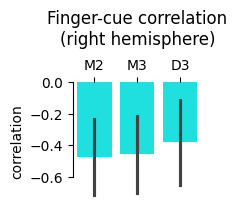

In [57]:
from vis import plot_interaction, add_sig_to_bars

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'M.exec.p'), 'feature')
n_param_f = Mf.n_param
interaction = {'roi': [], 'interaction': [],}
pcm_path = os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir)
for roi in rois:
    f = open(os.path.join(pcm_path, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    theta = param[idxf][:n_param_f]
    theta2 = theta ** 2
    covariance = theta[1] * theta[2]
    stds = np.sqrt((theta2[0] + theta2[1]) * theta2[2])
    correlation = covariance / stds
    interaction['roi'].extend([roi] * theta.shape[1])
    interaction['interaction'].extend(correlation if (np.isclose(stds, 0).sum() / stds.size) < .6 else [None] * theta.shape[1])
fig, ax = plt.subplots(figsize=(2, 2), constrained_layout=True)
fig, ax = plot_interaction(fig, ax, interaction)
fig, ax = add_sig_to_bars(fig, ax, interaction, y='interaction', x='roi')
ax.spines['left'].set_bounds(ax.get_yticks()[1], ax.get_yticks()[-1])
ax.set_title('Finger-cue correlation\n(right hemisphere)', pad=10)
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

M2: tval=1.6936341221312958, pval=0.11610921452456476
M3: tval=1.9112200936816115, pval=0.08015173102790601
D3: tval=2.37225466887897, pval=0.035256466569051


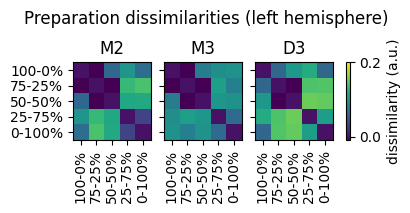

In [58]:
H = 'L'

vmin, vmax = -.01, .2

fig, axs = plt.subplots(1, len(rois), figsize=(4, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_dissimilarities(fig, axs, r, G, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.015)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Preparation dissimilarities (left hemisphere)')

plt.show()

cue vs. uncertainty, tval=0.6180449566880895, pval=0.5480965101600438
cue vs. uncertainty, tval=0.9919712025813531, pval=0.3407930946214013
cue vs. uncertainty, tval=-0.3481189259182982, pval=0.733781474317029


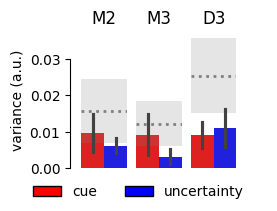

In [59]:
Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.p'), 'component')
n_param_c = Mc.n_param
components = ['cue', 'uncertainty']
palette = ['red', 'blue']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(2, 2), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    G = np.load(os.path.join(gl.baseDir, experiment, 'SUIT',gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_var_expl(fig, axs, r, G, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, 'SUIT',gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()

M2: tval=1.5974677658735388, pval=0.13614456246234377
M3: tval=1.9814624007401047, pval=0.07092175449616461
D3: tval=1.6334072434783684, pval=0.12832772812248586


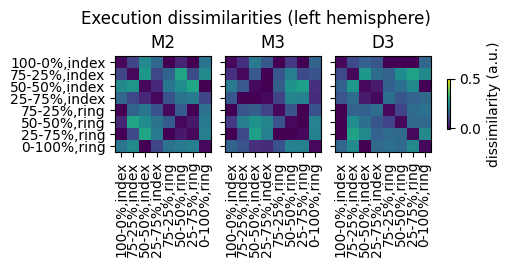

In [60]:
vmin, vmax = -.01, .5

fig, axs = plt.subplots(1, len(rois), figsize=(5, 2.5),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_dissimilarities(fig, axs, r, G, list(gl.regressor_mapping.keys())[5:13], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Execution dissimilarities (left hemisphere)')

plt.show()

finger vs. cue, tval=0.5907184397895789, pval=0.5656689488400279
finger vs. surprise, tval=1.4214869573794189, pval=0.18063988585378174
cue vs. surprise, tval=2.1814736138148594, pval=0.049762324308739996
finger vs. cue, tval=1.1500085334380945, pval=0.2725434553172581
finger vs. surprise, tval=1.30552886192975, pval=0.21618860248988064
cue vs. surprise, tval=1.1487006774472448, pval=0.2730618349263903
finger vs. cue, tval=-1.2482494019042827, pval=0.235745916968242
finger vs. surprise, tval=1.46876850202888, pval=0.167616666424895
cue vs. surprise, tval=2.520015586824347, pval=0.026908428549256628


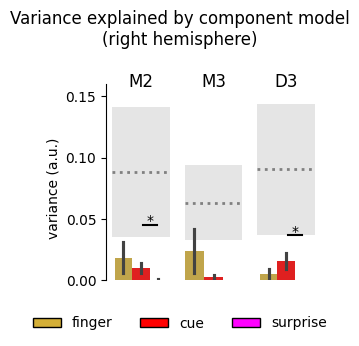

In [61]:
Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.p'), 'component')
n_param_c = Mc.n_param
components = ['finger', 'cue', 'surprise']
palette = ['#D4AF37', 'red', 'magenta']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(3, 3), sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, 'SUIT',gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    G = np.load(os.path.join(gl.baseDir, experiment,'SUIT', gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_var_expl(fig, axs, r, G, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, 'SUIT',gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='upper center', frameon=False, ncol=len(components), fontsize=10, bbox_to_anchor=(0.5, 0))
fig.suptitle('Variance explained by component model\n(right hemisphere)')
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-1])
fig.tight_layout()
plt.show()

M2, tval=-1.542996341112852, pval=0.14878121490661753
M3, tval=-0.5990360892871986, pval=0.5602879996995598
D3, tval=-1.1496763051186611, pval=0.2726750647297652


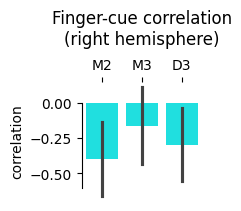

In [62]:
Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'M.exec.p'), 'feature')
n_param_f = Mf.n_param
interaction = {'roi': [], 'interaction': [],}
pcm_path = os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir)
for roi in rois:
    f = open(os.path.join(pcm_path, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    theta = param[idxf][:n_param_f]
    theta2 = theta ** 2
    covariance = theta[1] * theta[2]
    stds = np.sqrt((theta2[0] + theta2[1]) * theta2[2])
    correlation = covariance / stds
    interaction['roi'].extend([roi] * theta.shape[1])
    interaction['interaction'].extend(correlation if (np.isclose(stds, 0).sum() / stds.size) < .6 else [None] * theta.shape[1])
fig, ax = plt.subplots(figsize=(2, 2), constrained_layout=True)
fig, ax = plot_interaction(fig, ax, interaction)
fig, ax = add_sig_to_bars(fig, ax, interaction, y='interaction', x='roi')
ax.spines['left'].set_bounds(ax.get_yticks()[1], ax.get_yticks()[-2])
ax.set_title('Finger-cue correlation\n(right hemisphere)', pad=10)
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()